In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
from astropy.table import vstack, Table

# SLSim and Speclite imports
import speclite.filters
import slsim
import slsim.Sources as sources
import slsim.Pipelines as pipelines
import slsim.Deflectors as deflectors
from slsim.Lenses.lens_pop import LensPop
from slsim.Sources.SourceCatalogues.QuasarCatalog.quasar_pop import QuasarRate
from slsim.ImageSimulation.image_simulation import simulate_image, rgb_image_from_image_list
from slsim.Pipelines import roman_speclite

from utils.anim import create_lensing_animation
from utils.lsst_cadence import get_rubin_cadence_dict


import midex_instrument

%load_ext autoreload
%autoreload 2

/home/paras/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SkyPy config successfully generated at: configs/roman-lsst-MidEx-like.yml


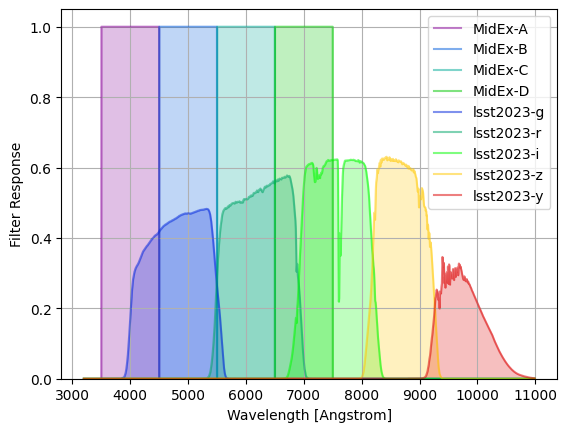

In [2]:
# ==========================================
# 1. INITIALIZE ENVIRONMENT & CONFIGS
# ==========================================
# Generate the YAML file dynamically from the specs in midex_instrument.py
skypy_config_path = os.path.join("configs", "roman-lsst-MidEx-like.yml")
midex_instrument.generate_skypy_config(output_path=skypy_config_path)

# Register custom filters into speclite's active memory
midex_instrument.configure_midex_filters()
roman_speclite.configure_roman_filters()

# Dynamically grab the MidEx band names (e.g., ['MidEx-A', 'MidEx-B', ...])
midex_filter_names = midex_instrument.get_midex_band_names()

# names with no "MidEx-" prefix
midex_filter_names_no_prefix = [name.replace("MidEx-", "") for name in midex_filter_names]

# Load all filters required for the simulation
filters = speclite.filters.load_filters(
    *midex_filter_names,
    "lsst2023-g", "lsst2023-r", "lsst2023-i", "lsst2023-z", "lsst2023-y",
    # "Roman-F062", "Roman-F087", "Roman-F106", "Roman-F129",
    # "Roman-F158", "Roman-F184", "Roman-F146", "Roman-F213"
)

# plot the filter curves to verify they are loaded correctly
speclite.filters.plot_filters(filters)

## Make Lens Populations

In [3]:
# ==========================================
# 2. POPULATION SETUP
# ==========================================
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

galaxy_sky_area = Quantity(value=2, unit="deg2")
quasar_sky_area = Quantity(value=5, unit="deg2")
full_sky_area = Quantity(value=10, unit="deg2")

kwargs_deflector_cut = {"band": "i", "band_max": 28, "z_min": 0.01, "z_max": 2.5}
kwargs_source_cut = {"band": "i", "band_max": 26, "z_min": 0.001, "z_max": 5.0}

# Generate background galaxies
# NOTE: z_max is capped at 3.0 to prevent kcorrect UV template extrapolation errors for extremely blue filters.
galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=skypy_config_path,
    sky_area=galaxy_sky_area,
    filters=None,
    cosmo=cosmo,
    z_min=0.0,
    z_max=3.0, 
)

In [4]:
host_galaxy_candidates = vstack(
    [galaxy_simulation_pipeline.red_galaxies, galaxy_simulation_pipeline.blue_galaxies],
    join_type="exact",
)

lens_galaxies = deflectors.AllLensGalaxies(
    red_galaxy_list=galaxy_simulation_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_simulation_pipeline.blue_galaxies,
    kwargs_cut=kwargs_deflector_cut,
    kwargs_mass2light={},
    cosmo=cosmo,
    sky_area=galaxy_sky_area,
)

/home/paras/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:56: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  red_galaxy_list = catalog_with_angular_size_in_arcsec(
/home/paras/repos/self/slsim/slsim/Deflectors/DeflectorPopulation/all_lens_galaxies.py:59: UserWarning: Angular size is converted to arcsec because provided input_catalog_type is skypy. If this is not correct, please refer to the documentation of the class you are using
  blue_galaxy_list = catalog_with_angular_size_in_arcsec(


In [ ]:
# ==========================================
# 3. QUASAR GENERATION
# ==========================================
# Combine all bands dynamically for qsogen
all_qsogen_bands = [
    "F062", "F087", "F106", "F129", "F158", "F184", "F146", "F213", # Roman
    "g", "r", "i", "z", "y",                                        # LSST
]

if os.path.exists(f"data/agn+host_catalog_{quasar_sky_area.value}_deg2.fits"):
    print("Quasar catalog already exists. Loading from file...")
    quasar_source = Table.read(f"data/agn+host_catalog_{quasar_sky_area.value}_deg2.fits")
else:
    quasar_class = QuasarRate(
        skypy_config=skypy_config_path,
        cosmo=cosmo,
        sky_area=quasar_sky_area,
        noise=True,
        redshifts=np.linspace(0.001, 5.01, 100),
        host_galaxy_candidate=host_galaxy_candidates,
        use_qsogen_sed=True,
        qsogen_bands=all_qsogen_bands + midex_filter_names_no_prefix,  # Ensure all MidEx bands are included in the SED generation
        use_sed_interpolator=True,
    )

    quasar_source = quasar_class.quasar_sample(m_min=15, m_max=30, host_galaxy=True)
    quasar_source.write(f"data/agn+host_catalog_{quasar_sky_area.value}_deg2.fits", overwrite=True)

kwargs_variability = set( all_qsogen_bands + midex_filter_names_no_prefix)

kwargs_quasar = {
    "variability_model": "light_curve",
    "kwargs_variability": kwargs_variability,
    "agn_driving_variability_model": "bending_power_law",
    "agn_driving_kwargs_variability": {
        "length_of_light_curve": 35000,
        "time_resolution": 1,
        "log_breakpoint_frequency": 1 / 20,
        "low_frequency_slope": 1,
        "high_frequency_slope": 3,
        "standard_deviation": 0.9,
    },
    "lightcurve_time": np.linspace(-5000, 30000, 35000),
    "corona_height": 10,
    "r_resolution": 500,
}

source_quasar = sources.PointPlusExtendedSources(
    point_plus_extended_sources_list=quasar_source,
    cosmo=cosmo,
    sky_area=quasar_sky_area,
    kwargs_cut=kwargs_source_cut,
    list_type="astropy_table",
    catalog_type="skypy",
    point_source_type="quasar",
    extended_source_type="single_sersic",
    point_source_kwargs=kwargs_quasar,
)

Matching quasars with host galaxies: 100%|██████████| 52838/52838 [00:11<00:00, 4709.73it/s]


## Select Lens

In [27]:
# ==========================================
# 4. LENSING SIMULATION & RENDERING
# ==========================================
quasar_lens_pop = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_quasar,
    cosmo=cosmo,
    sky_area=full_sky_area * 100,
)

kwargs_lens_cut = {
    "min_image_separation": 0.5, 
    "max_image_separation": 10, 
    "second_brightest_image_cut": {"i": 26}
}

selected_lenses = quasar_lens_pop.draw_population(kwargs_lens_cuts=kwargs_lens_cut, speed_factor=10000)

quad_lenses = [lens for lens in selected_lenses if lens.image_number[0] == 4]

LENS SYSTEM PROPERTIES
Number of Images:    [4]
Einstein Radius:     0.8958 arcsec
Source Redshift:     2.6020
Deflector Redshift:  0.5582
--------------------------------------------------
Microlensing Parameters (band='i', source_index=0):
Kappa Star:          [0.18158872 0.19373134 0.21279738 0.2569232 ]
Kappa Total:         [0.4261867  0.43751583 0.5474429  0.60734567]
Shear:               [0.41320075 0.43250349 0.578944   0.63720531]
Shear Angle:         [ 1.12500636  2.36079424 -1.67388198 -1.34052068]


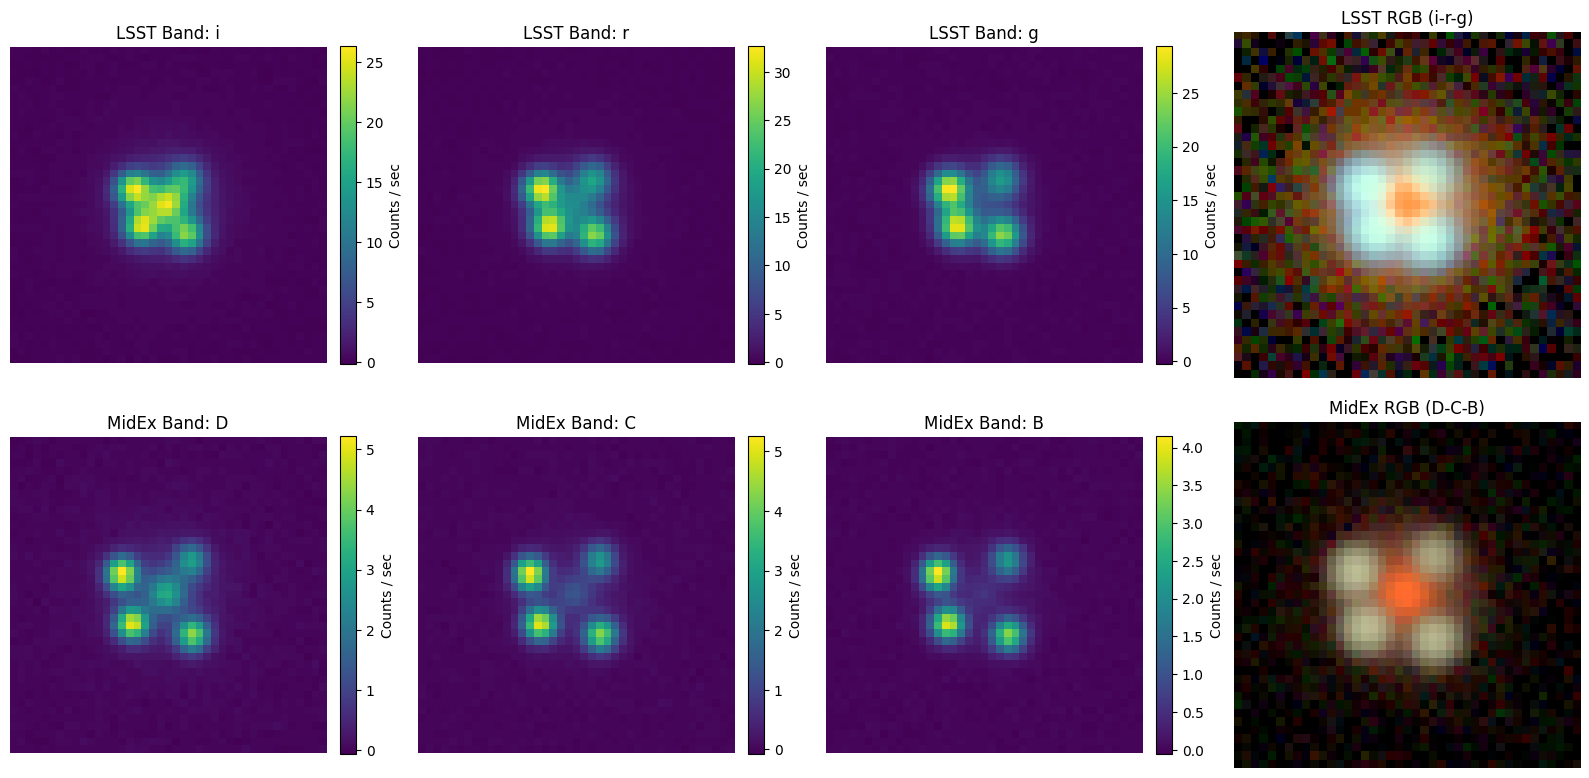

In [ ]:
if quad_lenses:
    # --- 1. Select the lens ---
    image_separations = [lens.einstein_radius[0] for lens in quad_lenses]
    largest_image_separation_index = np.argmax(image_separations)
    lens_class = quad_lenses[largest_image_separation_index]

    # --- 2. Print Properties Nicely ---
    print("=" * 50)
    print("LENS SYSTEM PROPERTIES")
    print("=" * 50)
    print(f"Number of Images:    {lens_class.image_number}")
    print(f"Einstein Radius:     {lens_class.einstein_radius[0]:.4f} arcsec")
    print(f"Source Redshift:     {lens_class.source_redshift_list[0]:.4f}")
    print(f"Deflector Redshift:  {lens_class.deflector_redshift:.4f}")
    
    kappa_star, kappa_tot, shear, shear_angle = lens_class._microlensing_parameters_for_image_positions_single_source(band="i", source_index=0)
    
    print("-" * 50)
    print("Microlensing Parameters (band='i', source_index=0):")
    print(f"Kappa Star:          {kappa_star}")
    print(f"Kappa Total:         {kappa_tot}")
    print(f"Shear:               {shear}")
    print(f"Shear Angle:         {shear_angle}")
    print("=" * 50)

    # --- 3. Simulation Setup ---
    num_pix = 41
    stretch_value = 0.5  # Adjust this value to change RGB brightness/contrast
    
    # Define bands mapping to [Red, Green, Blue]
    lsst_bands = ["i", "r", "g"]  
    midex_bands = ["D", "C", "B"] 
    
    lsst_images = []
    midex_images = []

    # Simulate LSST Images
    for b in lsst_bands:
        img = simulate_image(
            lens_class, 
            band=b,
            observatory="LSST",
            num_pix=num_pix, 
            microlensing=True
        )
        lsst_images.append(img)
        
    # Simulate MidEx Images
    for b in midex_bands:
        img = simulate_image(
            lens_class, 
            band=b,
            observatory="MidEx",
            num_pix=num_pix, 
            microlensing=True
        )
        midex_images.append(img)

    # --- 4. Generate RGB Composites ---
    lsst_rgb = rgb_image_from_image_list(lsst_images, stretch=stretch_value)
    midex_rgb = rgb_image_from_image_list(midex_images, stretch=stretch_value)

    # --- 5. Plotting ---
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Plot LSST Row
    for i, (ax, band, img) in enumerate(zip(axes[0, :3], lsst_bands, lsst_images)):
        im = ax.imshow(img, origin='lower', cmap='viridis')
        ax.set_title(f"LSST Band: {band}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Counts / sec')
        ax.axis('off')
        
    axes[0, 3].imshow(lsst_rgb, origin='lower')
    axes[0, 3].set_title(f"LSST RGB ({'-'.join(lsst_bands)})")
    axes[0, 3].axis('off')
    
    # Plot MidEx Row
    for i, (ax, band, img) in enumerate(zip(axes[1, :3], midex_bands, midex_images)):
        im = ax.imshow(img, origin='lower', cmap='viridis')
        ax.set_title(f"MidEx Band: {band}")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Counts / sec')
        ax.axis('off')
        
    axes[1, 3].imshow(midex_rgb, origin='lower')
    axes[1, 3].set_title(f"MidEx RGB ({'-'.join(midex_bands)})")
    axes[1, 3].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("No quad lenses found in this draw.")

## Cadence for each observatory

Fetching LSST Cadence from rubin_sim...
Generating MidEx Cadence...


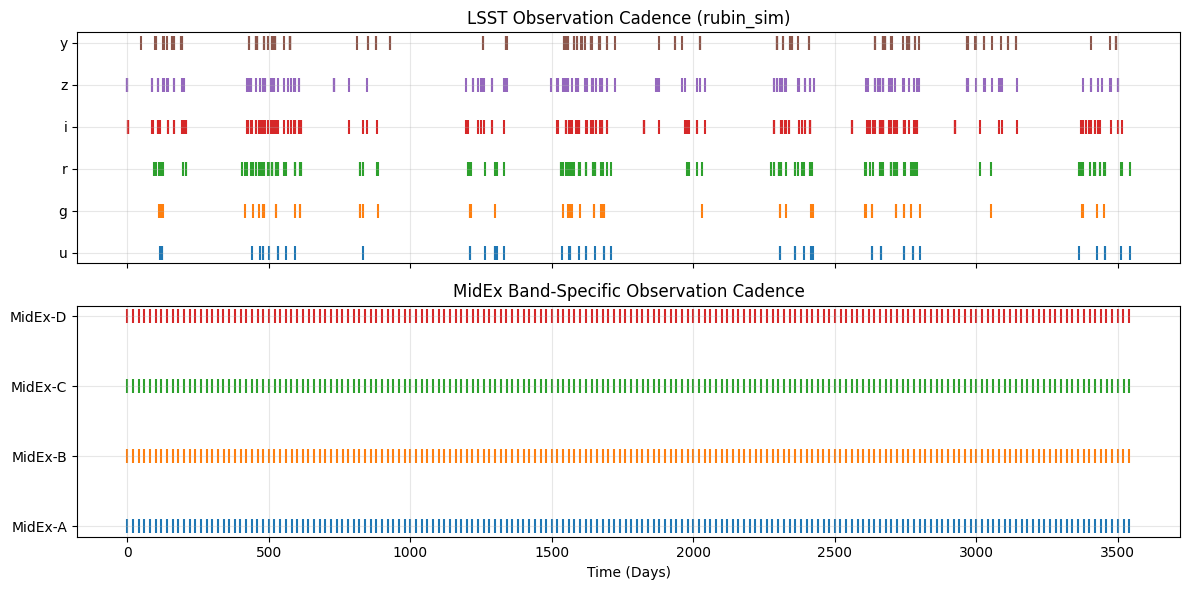

In [29]:
# =====================================================================
# 1. FETCH INDIVIDUAL CADENCES
# =====================================================================
print("Fetching LSST Cadence from rubin_sim...")
lsst_bands = ["u", "g", "r", "i", "z", "y"]
lsst_cadence_dict = get_rubin_cadence_dict(filters=lsst_bands, starting_time_offset=0)

# Determine the max duration of the LSST survey to match MidEx to it
max_lsst_time = max([np.max(lsst_cadence_dict[b]) for b in lsst_bands if len(lsst_cadence_dict[b]) > 0])

print("Generating MidEx Cadence...")
midex_cadence_dict = midex_instrument.get_midex_cadence_dict(
    duration_days=max_lsst_time, 
    starting_time_offset=0
)

combined_cadence_dict = {**lsst_cadence_dict, **midex_cadence_dict}

# =====================================================================
# 2. VISUALIZE THE CADENCE COMPARISON (Barcode Plot)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot LSST Cadence
for i, band in enumerate(lsst_bands):
    if len(lsst_cadence_dict[band]) > 0:
        ax1.scatter(lsst_cadence_dict[band], np.full_like(lsst_cadence_dict[band], i), 
                    marker='|', s=100, label=f"LSST {band}")
ax1.set_yticks(range(len(lsst_bands)))
ax1.set_yticklabels(lsst_bands)
ax1.set_title("LSST Observation Cadence (rubin_sim)")
ax1.grid(True, alpha=0.3)

# Plot MidEx Cadence
midex_bands = list(midex_cadence_dict.keys())
for i, band in enumerate(midex_bands):
    if len(midex_cadence_dict[band]) > 0:
        ax2.scatter(midex_cadence_dict[band], np.full_like(midex_cadence_dict[band], i), 
                    marker='|', s=100, label=f"MidEx {band}")
ax2.set_yticks(range(len(midex_bands)))
ax2.set_yticklabels([f"MidEx-{b}" for b in midex_bands])
ax2.set_title("MidEx Band-Specific Observation Cadence")
ax2.set_xlabel("Time (Days)")
ax2.grid(True, alpha=0.3)

# Zoom in on the first year to see the spacing clearly
# plt.xlim(0, 365) 
plt.tight_layout()
plt.show()

kwargs_magnification_map not in kwargs_microlensing. Using default magnification map kwargs.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.
Generating magnification map ...
Done generating magnification map.


Text(0.5, 0.98, 'Lensed Quasar Lightcurves with MidEx Cadence (Microlensing Included)')

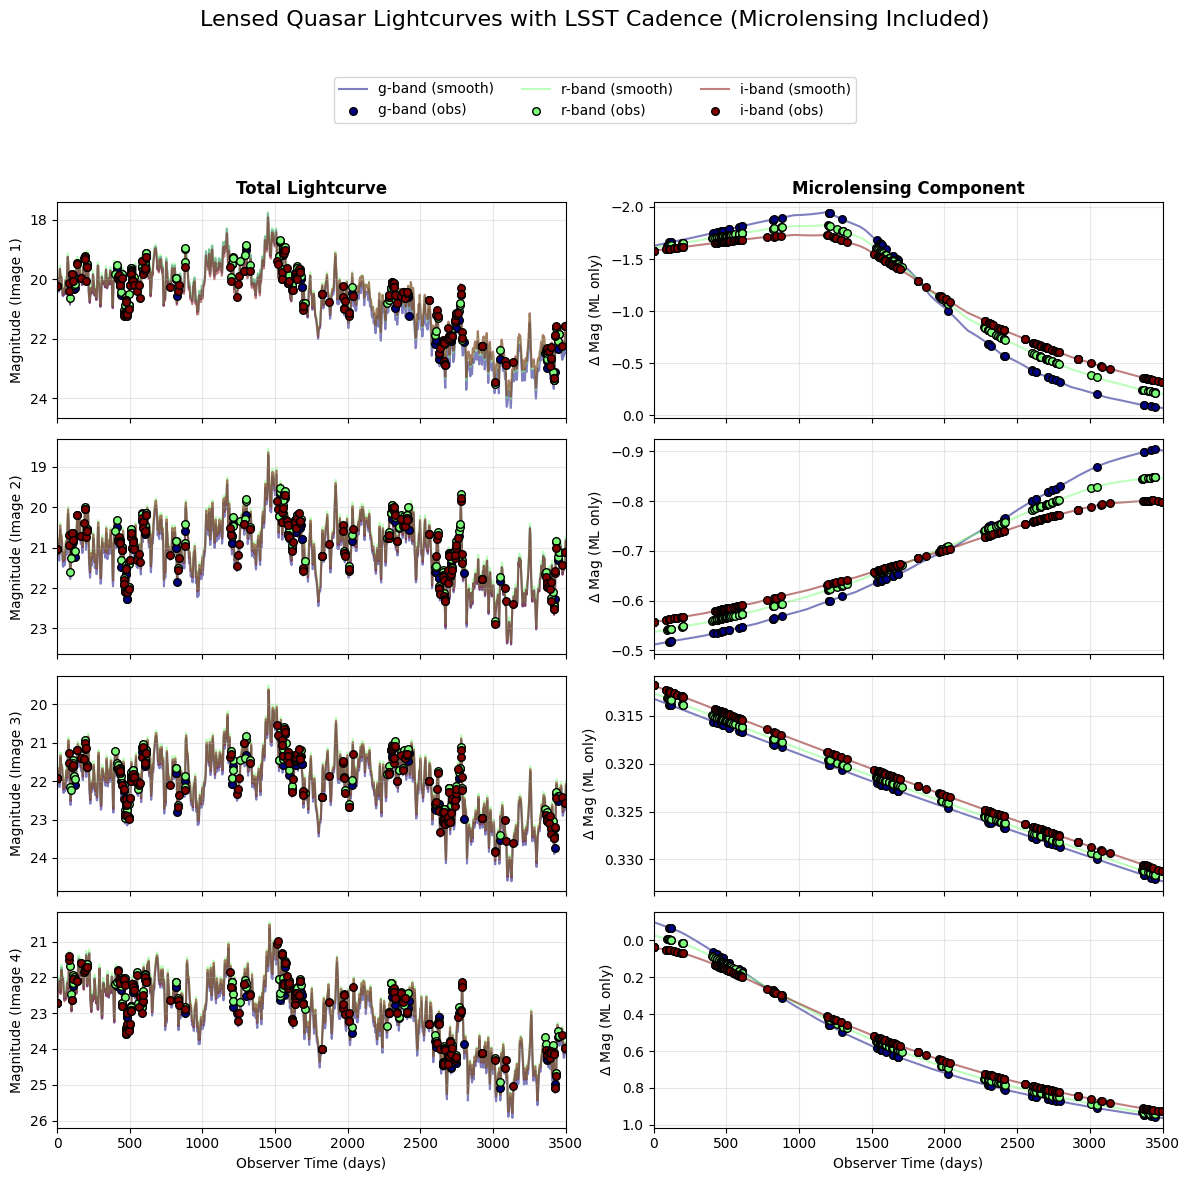

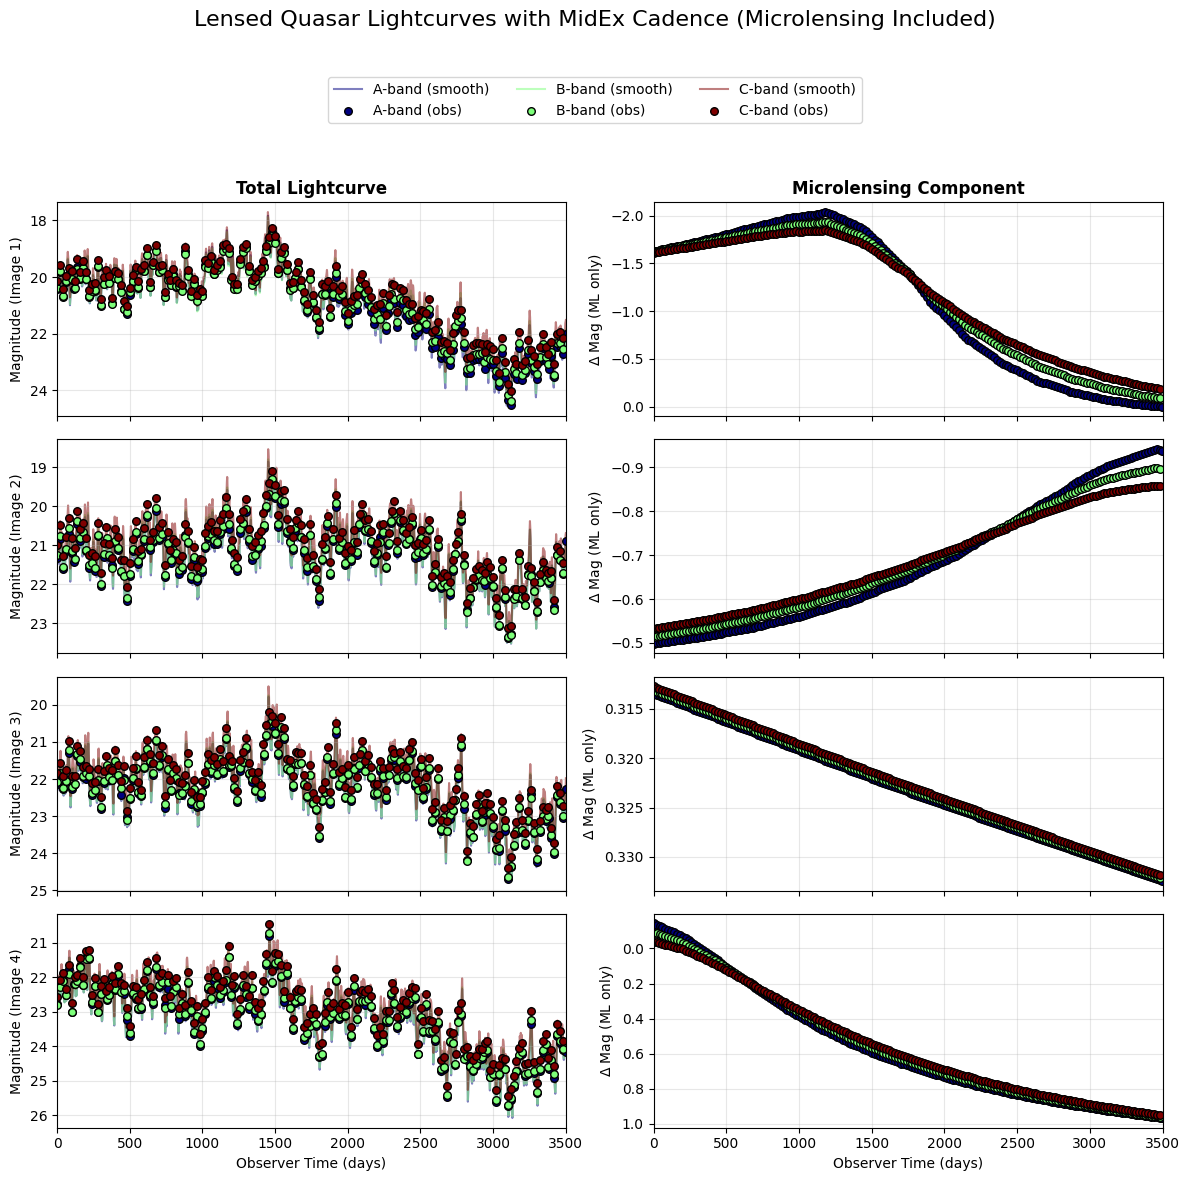

In [31]:
from utils.anim import plot_lightcurves
time_array = np.linspace(0, 3500, 3500)
# del lens_class.microlensing_model_class(0)._lc_start_position # resets microlensing tracks on magmap
fig = plot_lightcurves(lens_class, bands=["g", "r", "i"], 
                        smooth_time_array=time_array, microlensing=True, 
                        cadence_dict=lsst_cadence_dict,
                        time_limits=(0, 3500)
                        );
fig.suptitle("Lensed Quasar Lightcurves with LSST Cadence (Microlensing Included)", fontsize=16)

fig = plot_lightcurves(lens_class, bands=["A", "B", "C"], 
                        smooth_time_array=time_array, microlensing=True,
                        cadence_dict=midex_cadence_dict,
                        time_limits=(0, 3500)
                        );
fig.suptitle("Lensed Quasar Lightcurves with MidEx Cadence (Microlensing Included)", fontsize=16)